In [1]:
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", message="numpy.dtype size changed")

import dynamo as dyn

dyn.configuration.set_figure_params('dynamo', background='white')
dyn.pl.style(font_path='Arial')
dyn.get_all_dependencies_version()

%load_ext autoreload
%autoreload 2

Arial font downloaded successfully to: /var/folders/_0/8l2kpxvj13b9xcgqzjm3mkjw0000gn/T/dynamo_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered custom font as: Arial


 ███                               ████████        
█████   █████    █████    █████    ███   █████      
   ██████   ██████   ██████   ████████      ████ 
  ___                           ████            ███
 |   \ _  _ _ _  __ _ _ __  ___                 ███
 | |) | || | ' \/ _` | '  \/ _ \█████           ███ 
 |___/ \_, |_||_\__,_|_|_|_\___/█████       ████  
       |__/                        ███   █████     
Tutorial: https://dynamo-release.readthedocs.io/       
                                     █████      



package,ipykernel,numpy,setuptools,Pygments,igraph,datacache,tqdm,pynndescent,adjustText,networkx,umap-learn,pandas,get_version,mudata,dynamo-release,patsy,colorcet,numpy,numba,loompy,scikit-learn,seaborn,leidenalg,openpyxl,statsmodels,anndata,matplotlib,numdifftools,scipy,requests
version,6.30.1,2.0.2,80.9.0,2.19.1,1.0.0,1.4.1,4.67.3,0.6.0,1.3.0,3.2.1,0.5.11,2.3.3,3.5.5,0.2.4,1.5.2,1.0.2,3.1.0,2.0.2,0.60.0,3.0.8,1.6.1,0.13.2,0.11.0,3.1.5,0.14.6,0.10.9,3.9.4,0.9.41,1.13.1,2.32.5


In [20]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [56]:
adata=dyn.read('ZF3.h5ad')
adata

AnnData object with n_obs × n_vars = 58492 × 26133
    obs: 'clusters'
    obsm: 'X_pca', 'X_tsne'

In [57]:
preprocessor = dyn.pp.Preprocessor(cell_cycle_score_enable=True)
preprocessor.preprocess_adata(adata, recipe='monocle')
adata.obs['ntr'] = adata.obs['ntr'].astype(str) # Change to string because None values raise error at exporting
adata.var['ntr'] = adata.var['ntr'].astype(str)

|-----> Running monocle preprocessing pipeline...
|-----------> filtered out 0 outlier cells
|-----? No layers exist in adata, skipp filtering by shared counts
|-----------> filtered out 10319 outlier genes
|-----> PCA dimension reduction
|-----> <insert> X_pca to obsm in AnnData Object.
|-----> computing cell phase...
|-----? 
Dynamo is not able to perform cell cycle staging for you automatically. 
Since dyn.pl.phase_diagram in dynamo by default colors cells by its cell-cycle stage, 
you need to set color argument accordingly if confronting errors related to this.
|-----> [Preprocessor-monocle] completed [9.2161s]

╭─ SUMMARY: Preprocessor.preprocess_adata ───────────────────────────╮
│  Duration: 9.2231s                                                 │
│  Shape:    58,492 x 26,133 (Unchanged)                             │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────  

In [94]:
cluster_dict = {
    0: "Nascent forebrain neurons",
    1: "Granule cell neurons",
    2: "Ventral forebrain neurons",
    3: "tcf7l2+, barhl2+ neurons",
    4: "pou4f2+, barhl1a+ neurons",
    5: "Torus Longitudinalis neurons",
    6: "Granule cell neurons",
    7: "GABAergic optic tectum neurons",
    8: "Progenitor cells",
    9: "GABAergic optic tectum neurons",
    10: "GABAergic optic tectum neurons",
    11: "GABAergic optic tectum neurons",
    12: "rtn4rl2b+, eomesa+ pallium neurons",
    13: "atf5b+ neurons",
    14: "nefma+ glutamergic neurons (midbrain)",
    15: "GABAergic subpallium neurons",
    16: "tfap2b+, barhl2+ midbrain neurons",
    17: "Progenitor cells",
    18: "Torus Longitudinalis neurons",
    19: "Progenitor cells",
    20: "fezf1+, otpa+ neurons",
    21: "bnc2+, onecut1+ neurons",
    22: "Progenitor cells",
    23: "GABAergic hindbrain neurons",
    24: "unclassified neurons",
    25: "Radial glia cells (progenitors)",
    26: "Granule cell neurons",
    27: "sst3+ neurons",
    28: "hmx3a+, hmx2+ neurons",
    29: "phox2+ hindbrain neurons",
    30: "penkb+ neurons",
    31: "unclassified neurons",
    32: "rtn4rl2b+ pallium neurons",
    33: "Radial glia cells",
    34: "gng8+ neurons (dorsal habenula)",
    35: "pitx2+ neurons",
    36: "Oligodendrocyte precursor cells",
    37: "prdx1+ neurons",
    38: "pitx2+ neurons",
    39: "Microglia",
    40: "Ependymal cells",
    41: "Granule cell neurons",
    42: "Glutamergic neurons (telencephalon)",
    43: "Purkinje neurons",
    44: "Progenitor cells",
    45: "Oligodendrocytes",
    46: "Erythrocytes",
    47: "Oligodendrocytes",
    48: "Radial glia cells (progenitors)",
    49: "eomesa+ pallium neurons",
    50: "Endothelial cells",
    51: "T-cells/immune cells",
    52: "kiss1+ neurons (ventral habenula)",
    53: "sst1.1+, npy+ neurons",
    54: "Perivascular FGP cells",
    55: "Optic tectum neurons",
    56: "Cranial ganglion",
    57: "Cholinergic neurons",
    58: "Cranial ganglion",
    59: "Endothelial cells",
    60: "Cranial ganglion",
    61: "Statoacoustic ganglion",
    62: "aanat2+ neurons (pineal gland)",
    63: "None"
}

In [95]:
adata.obs['cell_type'] = adata.obs['clusters'].astype(int).map(cluster_dict)
adata.obs

,clusters,nGenes,nCounts,pMito,pass_basic_filter,Size_Factor,initial_cell_size,ntr,cell_type,cellBC
f1_DEW058_bcDQWR,2,2450,2171.061398,0,True,1.347112,2171.061398,None,Ventral forebrain neurons,NaN
f1_DEW058_bcAMXL,43,2007,2075.051360,0,True,1.287539,2075.051360,None,Purkinje neurons,NaN
f1_DEW058_bcGGJQ,10,1516,1920.189209,0,True,1.191449,1920.189209,None,GABAergic optic tectum neurons,NaN
f1_DEW058_bcGDTC,15,1308,1813.767639,0,True,1.125416,1813.767639,None,GABAergic subpallium neurons,NaN
f1_DEW058_bcAGDB,1,1028,1580.945932,0,True,0.980954,1580.945932,None,Granule cell neurons,NaN
...,...,...,...,...,...,...,...,...,...,...
hind_1506,23,830,1438.016530,0,True,0.892268,1438.016530,None,GABAergic hindbrain neurons,NaN
hind_1507,1,615,1202.357836,0,True,0.746045,1202.357836,None,Granule cell neurons,NaN
hind_1508,6,1106,1609.758291,0,True,0.998831,1609.758291,None,Granule cell neurons,NaN
hind_1509,17,705,1206.405579,0,True,0.748557,1206.405579,None,Progenitor cells,NaN


|-----------> plotting with basis key=X_tsne
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


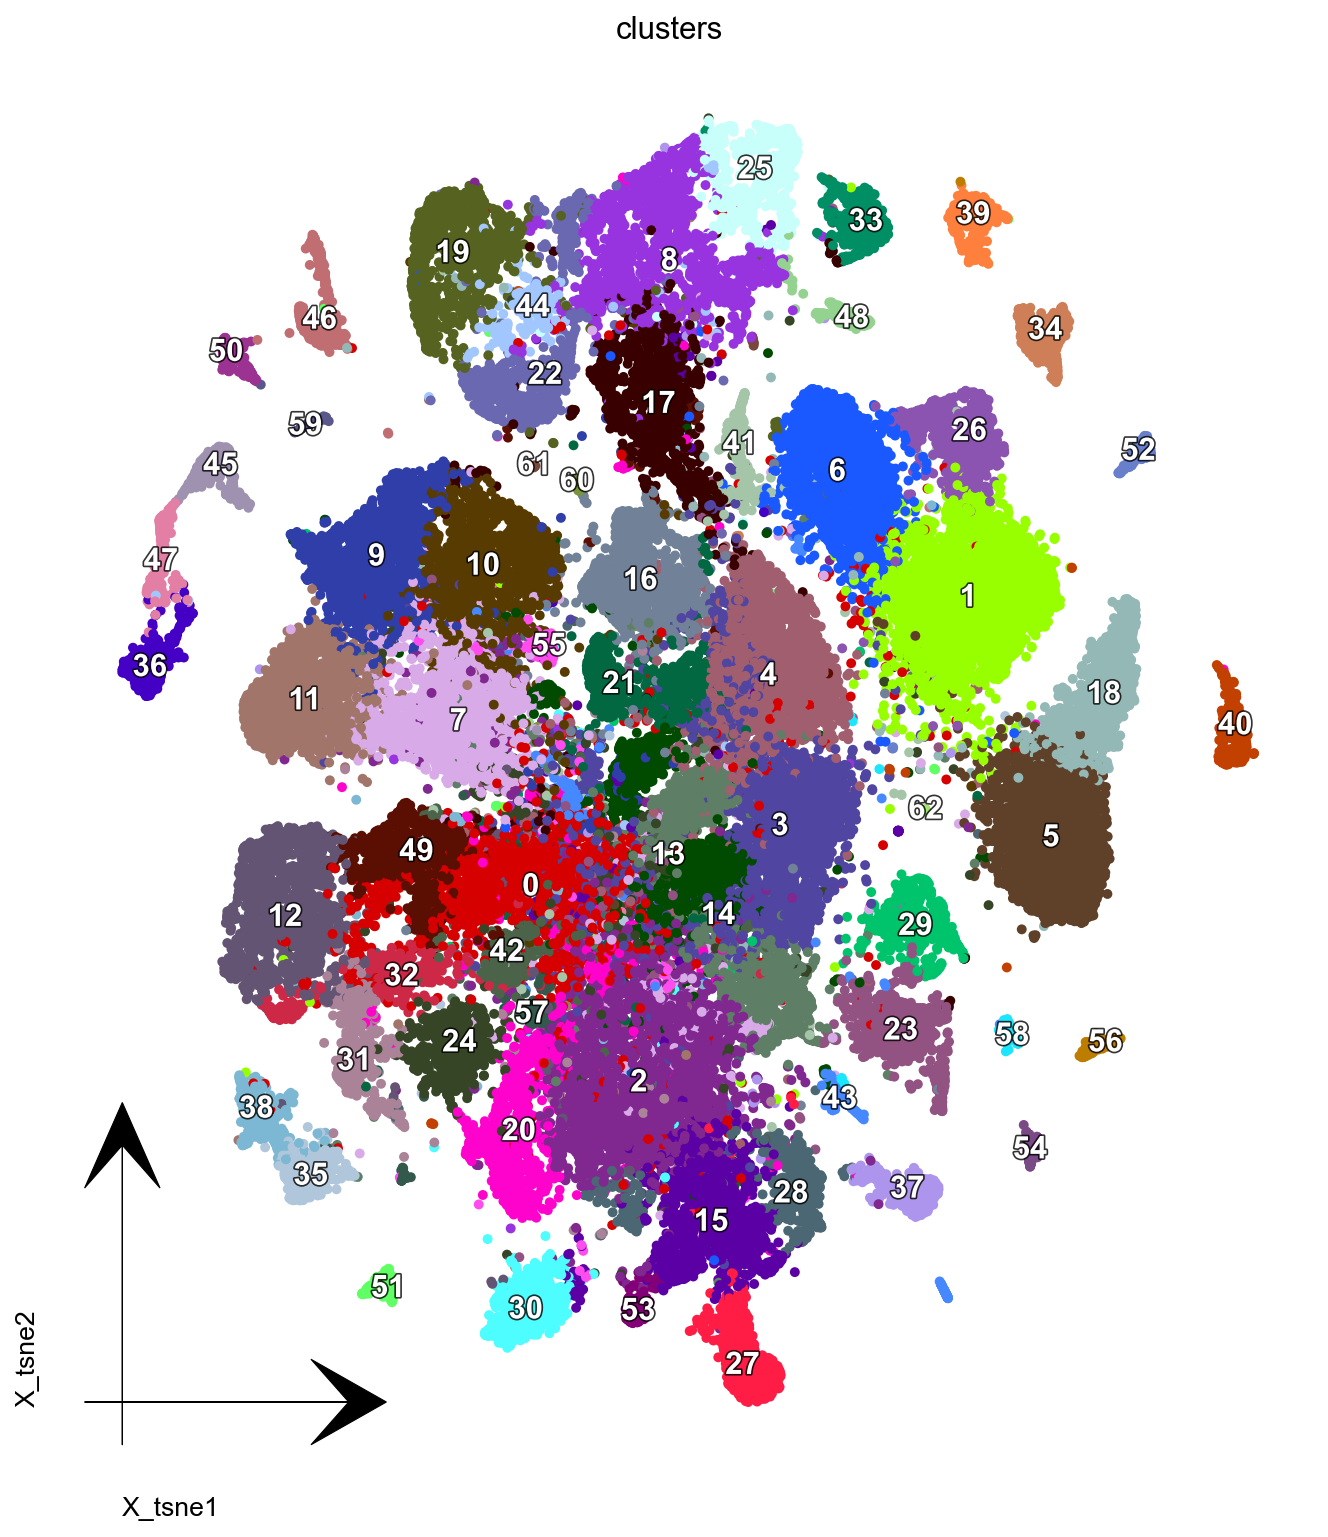

In [186]:
dyn.pl.tsne(adata, color='clusters', 
            figsize=(12,12),pointsize=0.3,alpha=1)

In [61]:
adata.write_h5ad('adata_temp.h5ad')

In [160]:
allele_table = pd.read_csv('ZF3_allele_table.csv').set_index('BarcodeKey')
allele_table

,Unnamed: 0,cellBC,intBC,allele,r1,r2,r3,r4,r5,r6,r7,r8,r9,r10,UMI,sampleID
BarcodeKey,,,,,,,,,,,,,,,,
f6_DEW142_bcAAVQ,0,F6-DEW142_AAACACGG-TAAGACGG,ZF3,59D+14159D+14159D+14199D+20899D+20899D+20899D+...,59D+141,59D+141,99D+208,99D+208,99D+208,99D+208,NONE,1I+356+C,NONE,NONE,39,ZF3
f6_DEW142_bcACDD,1,F6-DEW142_AAACCGCC-GCAAAGCC,ZF3,25I+140+GAAAGCTAGCGCCCTCGCCCTCGATNONENONE9D+21...,25I+140+GAAAGCTAGCGCCCTCGCCCTCGAT,NONE,9D+217,12D+244,NONE,NONE,NONE,NONE,NONE,NONE,38,ZF3
f6_DEW142_bcADBS,2,F6-DEW142_AAACGTGA-CCCATCTG,ZF3,NONE3I+163+CCC&53D+16753D+16753D+167349D+23734...,NONE,3I+163+CCC&53D+167,53D+167,349D+237,349D+237,349D+237,349D+237,349D+237,349D+237,349D+237,39,ZF3
f6_DEW142_bcAFZD,3,F6-DEW142_AAAGCCCG-ACTCACCG,ZF3,1549D+1271549D+1271549D+1271549D+1271549D+1271...,1549D+127,1549D+127,1549D+127,1549D+127,1549D+127,1549D+127,1549D+127,1549D+127,1549D+127,1549D+127,39,ZF3
f6_DEW142_bcAIZR,4,F6-DEW142_AACAGAAC-CTTCGCAC,ZF3,10D+131NONENONENONE374D+224374D+224374D+224374...,10D+131,NONE,NONE,374D+224,374D+224,374D+224,374D+224,374D+224,374D+224,374D+224,39,ZF3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
f6_DEW148_bcHKAV,371,F6-DEW148_TAGGTACG-ACTGAGTT,ZF3,140D+141140D+141140D+141140D+141140D+141140D+1...,140D+141,140D+141,140D+141,140D+141,140D+141,1I+301+A,NONE,NONE,NONE,NONE,38,ZF3
f6_DEW148_bcHWVT,372,F6-DEW148_TCGTGGGT-AGTGAAAG,ZF3,NONE3I+163+CCC&53D+16753D+16753D+167133D+23713...,NONE,3I+163+CCC&53D+167,53D+167,133D+237,133D+237,133D+237,133D+237,133D+237,133D+237,209D+375,40,ZF3
f6_DEW148_bcIAQM,373,F6-DEW148_TGAATCCT-GTTCAACT,ZF3,NONE3I+163+CCC&1I+167+TNONE9D+2171I+248+G82D+2...,NONE,3I+163+CCC&1I+167+T,9D+217,1I+248+G,82D+275,82D+275,82D+275,82D+275,82D+275,NONE,40,ZF3


In [197]:

adata.obs

,clusters,nGenes,nCounts,pMito,pass_basic_filter,Size_Factor,initial_cell_size,ntr,cell_type,cellBC
f1_DEW058_bcDQWR,2,2450,2171.061398,0,True,1.347112,2171.061398,None,Ventral forebrain neurons,NaN
f1_DEW058_bcAMXL,43,2007,2075.051360,0,True,1.287539,2075.051360,None,Purkinje neurons,NaN
f1_DEW058_bcGGJQ,10,1516,1920.189209,0,True,1.191449,1920.189209,None,GABAergic optic tectum neurons,NaN
f1_DEW058_bcGDTC,15,1308,1813.767639,0,True,1.125416,1813.767639,None,GABAergic subpallium neurons,NaN
f1_DEW058_bcAGDB,1,1028,1580.945932,0,True,0.980954,1580.945932,None,Granule cell neurons,NaN
...,...,...,...,...,...,...,...,...,...,...
hind_1506,23,830,1438.016530,0,True,0.892268,1438.016530,None,GABAergic hindbrain neurons,NaN
hind_1507,1,615,1202.357836,0,True,0.746045,1202.357836,None,Granule cell neurons,NaN
hind_1508,6,1106,1609.758291,0,True,0.998831,1609.758291,None,Granule cell neurons,NaN
hind_1509,17,705,1206.405579,0,True,0.748557,1206.405579,None,Progenitor cells,NaN


|-----------> plotting with basis key=X_tsne
|-----------> skip filtering lineage_cells by stack threshold when stacking color because it is not a numeric type


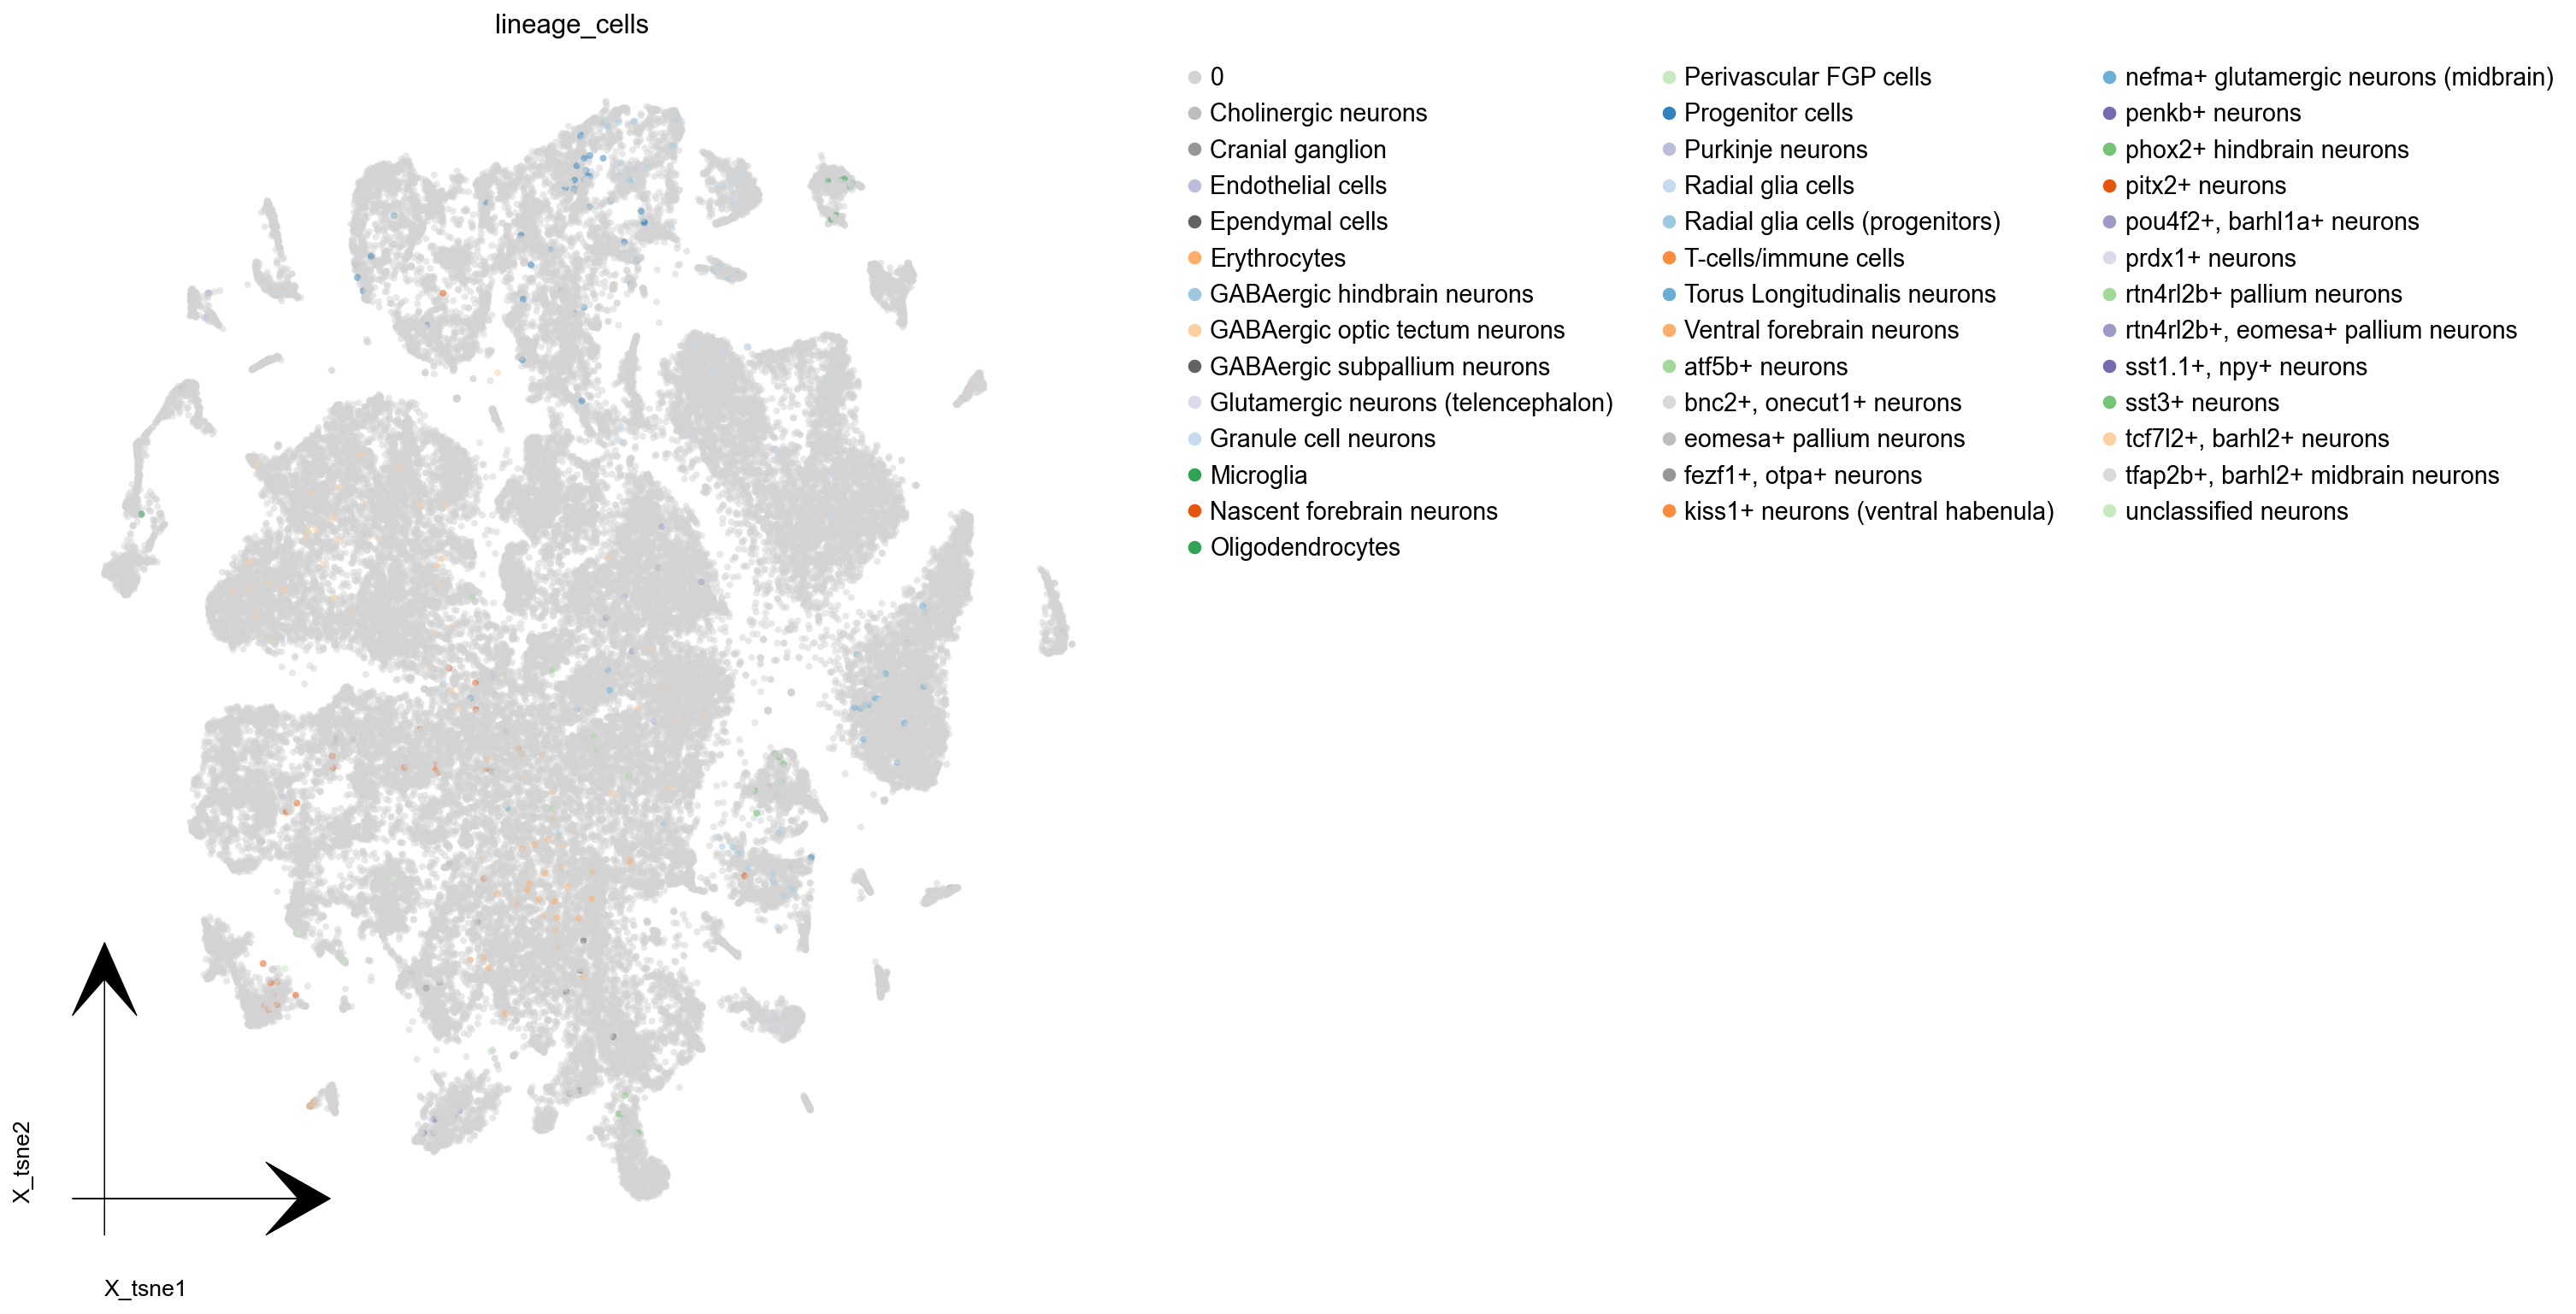

In [250]:
adata = dyn.read('adata_temp.h5ad')
adata.obs = adata.obs.join(allele_table['cellBC'], how='left')

lineage_series = adata.obs['cell_type'].astype(str)
lineage_series[adata.obs['cellBC'].isna()] = '0'
adata.obs['lineage_cells'] = pd.Categorical(lineage_series, ordered=True)

#adata.obs.sort_values('lineage_cells')

cell_types = adata.obs['lineage_cells'].unique().tolist()

cmap = plt.cm.get_cmap('tab20c', len(cell_types))
color_key = {ct: mcolors.to_hex(cmap(i)) for i, ct in enumerate(cell_types)}
color_key['0'] = '#d3d3d3'  # override with grey

dyn.pl.tsne(adata, 
            color='lineage_cells',
            color_key=color_key,
            figsize=(12, 12),
            show_legend='right',
            pointsize=0.2,
            alpha=0.5,
            sort='increasing')

|-----------> plotting with basis key=X_tsne
|-----------> skip filtering lineage_cells by stack threshold when stacking color because it is not a numeric type


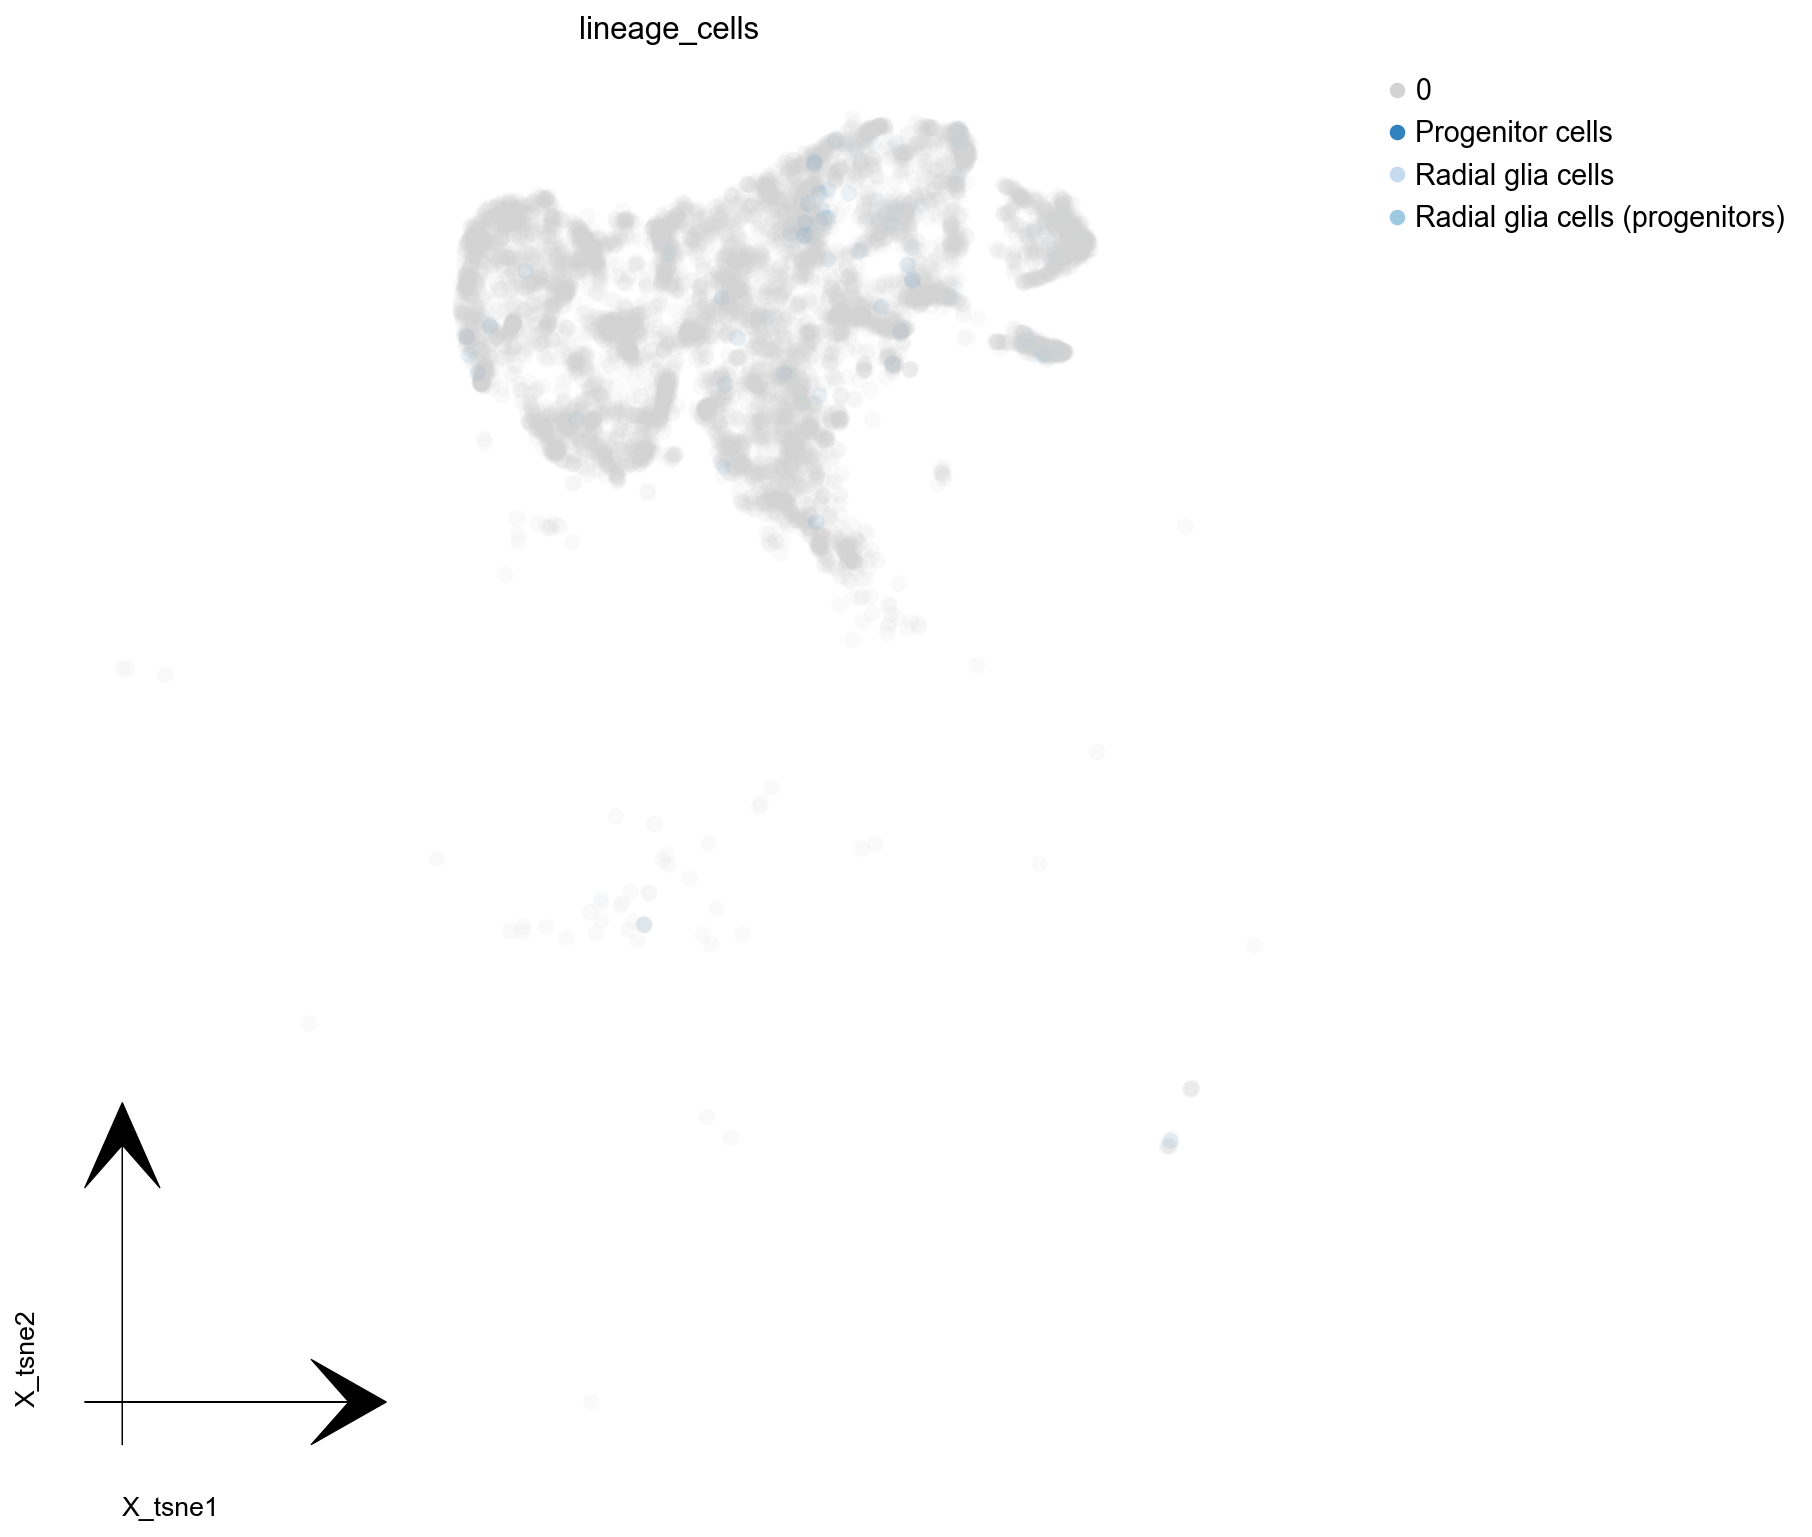

In [251]:
prog = adata[adata.obs['cell_type'].isin(["Progenitor cells", "Radial glia cells (progenitors)", "Radial glia cells"]), :].copy()
dyn.pl.tsne(prog, 
            color='lineage_cells',
            color_key=color_key,
            figsize=(12, 12),
            show_legend='right',
            pointsize=0.3,
            alpha=0.1,
            sort='increasing')

In [9]:
dyn.tl.neighbors(adata)

|-----> Start computing neighbor graph...
|-----------> X_data is None, fetching or recomputing...
|-----> fetching X data from layer:None, basis:pca
|-----> method arg is None, choosing methods automatically...
|-----------> method pynn selected


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.



╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 12.3242s                                                │
│  Shape:    58,492 x 26,133 (Unchanged)                             │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 30, 'method': None, 'metric': '...│
│                                                                    │
│  ● OBSP   │ ✚ connectivities (sparse matrix, 58492x58492)          │
│           │ ✚ distances (sparse matrix, 58492x58492)               │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


AnnData object with n_obs × n_vars = 58492 × 26133
    obs: 'clusters', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'Size_Factor', 'initial_cell_size', 'ntr', 'cell_type'
    var: 'nCells', 'nCounts', 'pass_basic_filter', 'log_m', 'score', 'log_cv', 'frac', 'use_for_pca', 'ntr'
    uns: 'pp', 'velocyto_SVR', 'feature_selection', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'history_log', 'clusters_colors', 'neighbors'
    obsm: 'X_pca', 'X_tsne'
    layers: 'M_s'
    obsp: 'distances', 'connectivities'

In [14]:
root_cells = adata.obs.index[adata.obs['cell_type'] == 'Radial glia cells (progenitors)']
adata.uns['iroot'] = list(adata.obs_names).index(root_cells[0])

sc.tl.dpt(adata)

|-----------> plotting with basis key=X_tsne


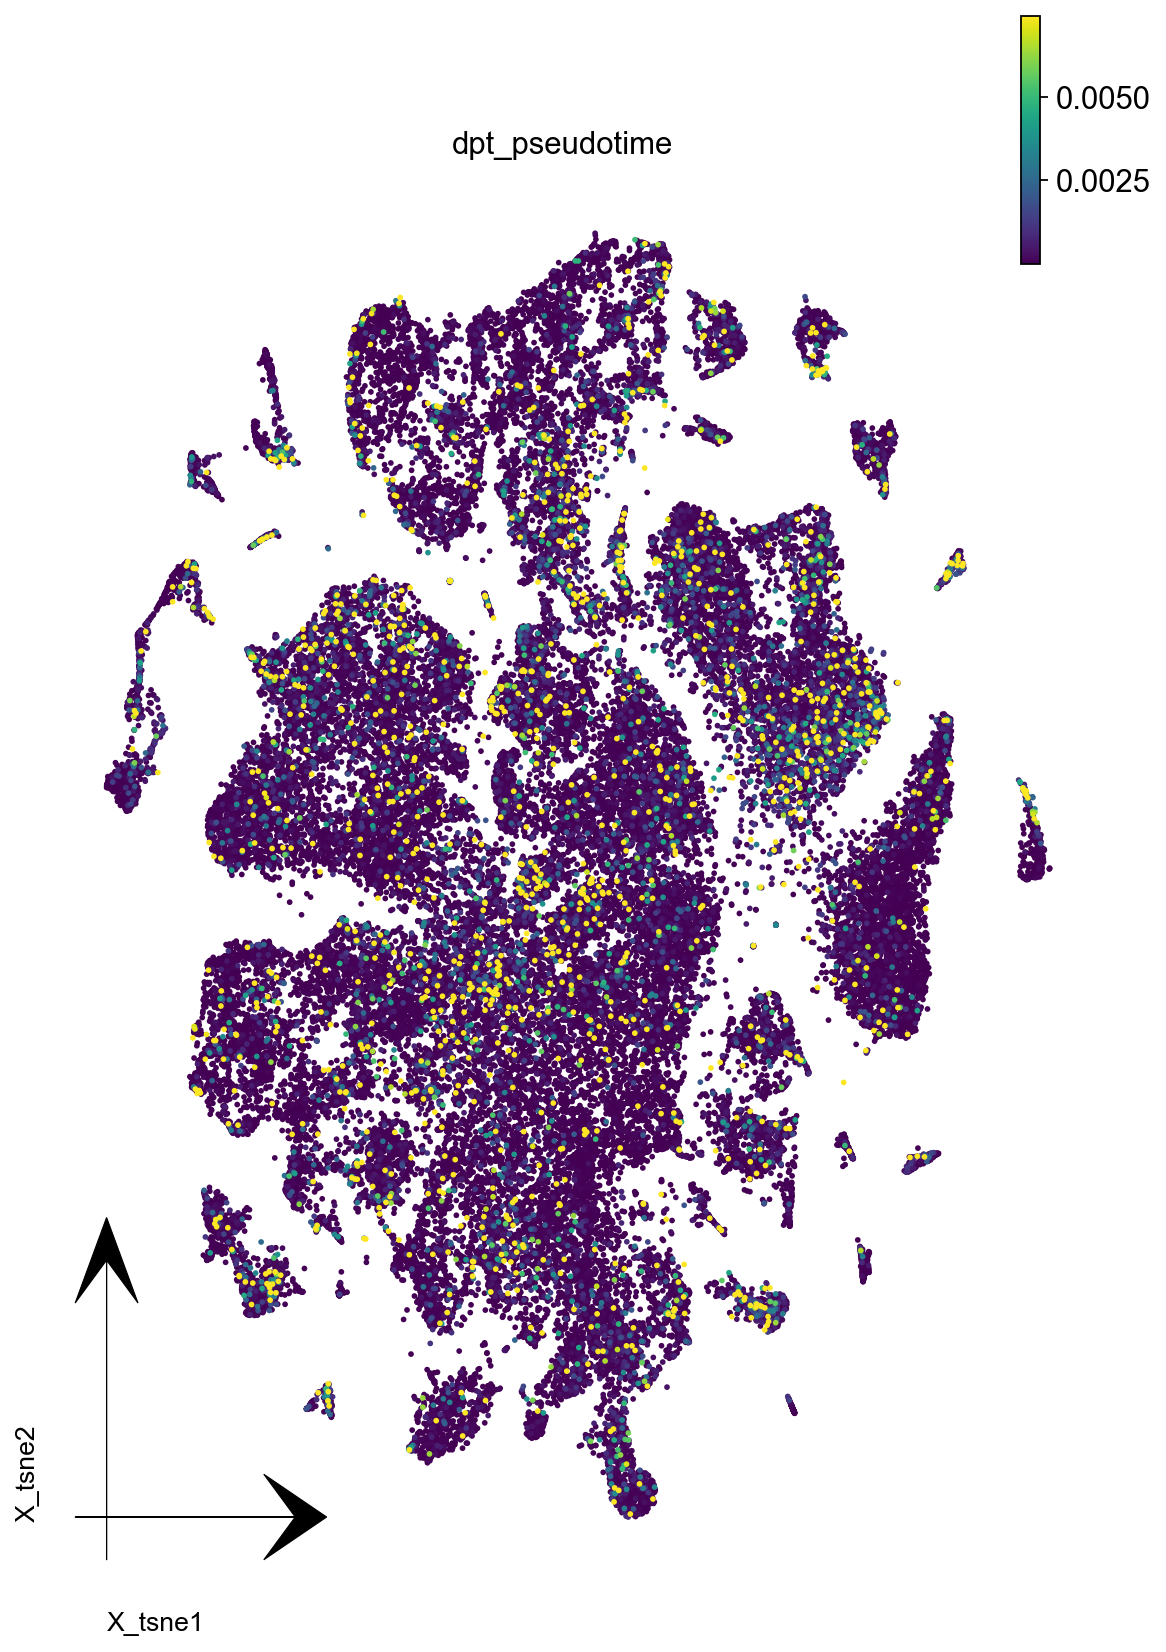

In [15]:
dyn.pl.tsne(adata, color='dpt_pseudotime', 
            figsize=(10,12),pointsize=0.1,alpha=1)

In [10]:
adata.layers['M_s']=adata.X
dyn.tl.pseudotime_velocity(adata,
                          pseudotime='palantir_pseudotime')

|-----> Embrace RNA velocity and velocity vector field analysis for pseudotime...
|-----> Retrieve neighbor graph and pseudotime...

╭─ SUMMARY: pseudotime_velocity ─────────────────────────────────────╮
│  Duration: 0.0011s                                                 │
│  Shape:    58,492 x 26,133 (Unchanged)                             │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯


KeyError: 'palantir_pseudotime'